In [1]:
import pandas as pd
from src.indices.ipp_calculator import IPPCalculator
from src.indices.equality_index_calculator import EqualityIndexCalculator


# Carregar dados dos parlamentares

In [2]:
df_parls_raw = pd.read_csv(
    "./data/df_parlamentares_por_legislatura.csv", 
)

legislaturas = df_parls_raw["idLegislatura"].unique()

# parlamentares únicos por legislatura
df_parls_raw = df_parls_raw[['id', 'idLegislatura']].drop_duplicates()

df_parl_detalhes = pd.read_csv(
    "./data/df_parl_detalhes.csv", index_col=0, dtype={"cpf": str}
)

df_parls_raw = df_parls_raw.merge(df_parl_detalhes, left_on="id", right_on="id", how="left")

df_parls_raw["cpf"] = df_parls_raw["cpf"].astype(str).str.zfill(11)
df_parls_raw.groupby("idLegislatura").size()

idLegislatura
48    589
49    620
50    635
51    642
52    626
53    636
54    671
55    623
56    613
57    595
dtype: int64

## Load race data

In [3]:
df_tse_candidatos = pd.read_csv("./data/df_tse_candidatos.csv")
df_tse_candidatos["cpf"] = df_tse_candidatos["cpf"].astype(str).str.zfill(11)

df_tse_candidatos = df_tse_candidatos[["cpf", "raca"]].dropna()



In [4]:
df_parls_raw_with_race = df_parls_raw.merge(
    df_tse_candidatos.drop_duplicates(subset="cpf", keep="last"), on="cpf", how="left" # TODO, estou mantendo apenas o último registro...
)
df_parls_raw_with_race.groupby("idLegislatura").size()

idLegislatura
48    589
49    620
50    635
51    642
52    626
53    636
54    671
55    623
56    613
57    595
dtype: int64

## Add race data

In [5]:
# Equality data
df_parls = df_parls_raw.copy()

df_parls = df_parls.join(pd.get_dummies(df_parls["sexo"]))
df_parls = df_parls.join(pd.get_dummies(df_parls["escolaridade"]))
df_parls = df_parls.join(pd.get_dummies(df_parls_raw_with_race["raca"]))

df_parls.set_index(["id", "idLegislatura"], inplace=True)


## Define your population proportions
population_proportions = {
    "F": 0.52,
    "M": 0.48,
    "branca": 0.2,
    "parda": 0.4,
    "preta": 0.1,
    "amarela": 0.05,
    "indigena": 0.05,
}
df_for_equality = df_parls[population_proportions.keys()].astype(int).copy()

In [ ]:
df_for_equality.loc[pd.IndexSlice[:, 56], :].describe()

,F,M,branca,parda,preta,amarela,indigena
count,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000,613.000000
mean,0.148450,0.851550,0.753670,0.197390,0.044046,0.003263,0.001631
std,0.355836,0.355836,0.431225,0.398354,0.205364,0.057073,0.040390
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Load IPP data

In [7]:
# IPP data
df = pd.read_excel("./outputs/df_ipp_v2f.xlsx")
df.set_index(["id", "idLegislatura"], inplace=True)

# Calculate indexes

## Calcular IPP

In [8]:
# Calculate IPP
ipp_calculator = IPPCalculator()
df_with_ipp = pd.DataFrame()
for legislatura in legislaturas:
    df_legislatura = df.loc[pd.IndexSlice[:, legislatura], :]
    df_calc = ipp_calculator.calculate(df_legislatura)
    df_with_ipp = pd.concat([df_with_ipp, df_calc])

## Calcular Equality index

In [9]:
df_for_equality.describe()

,F,M,branca,parda,preta,amarela,indigena
count,6250.000000,6250.000000,6250.000000,6250.00000,6250.000000,6250.000000,6250.000000
mean,0.090880,0.909120,0.510240,0.11920,0.027040,0.003200,0.000960
std,0.287461,0.287461,0.499935,0.32405,0.162213,0.056482,0.030971
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [38]:
aggeregated_index = []
df_with_equality = pd.DataFrame()
for legislatura in legislaturas:
    df_legislatura = df_for_equality.loc[pd.IndexSlice[:, legislatura], :]

    # Calculate equality index
    calculator = EqualityIndexCalculator()
    df_calc = calculator.calculate(
        df_legislatura,
        population_proportions,
        normalization_method="gini_based",
        weight_normalization_method="z_score",
    )

    df_with_equality = pd.concat([df_with_equality, df_calc])

    aggeregated_index.append(
        {
            "legislatura": legislatura,
            "index": calculator.adjustment_index,
            "normalized_index": calculator.normalized_index,
        }
    )


# Print adjustment index
print(f"Overall Equality Index: {calculator.adjustment_index:.4f}")
print(f"Overall Normalized Equality Index: {calculator.normalized_index:.4f}")

# Analyze weights distribution
print("\nWeight Distribution Summary:")
print(df_with_equality[["equality_weight", "equality_weight_normalized"]].describe())

Overall Equality Index: 0.2510
Overall Normalized Equality Index: 0.5791

Weight Distribution Summary:
       equality_weight  equality_weight_normalized
count      6250.000000                 6250.000000
mean          1.000000                    0.478112
std           1.442302                    0.168832
min           0.288232                    0.345503
25%           0.293712                    0.379595
50%           0.462664                    0.407404
75%           0.873829                    0.483443
max          18.973810                    1.000000


<Axes: xlabel='legislatura'>

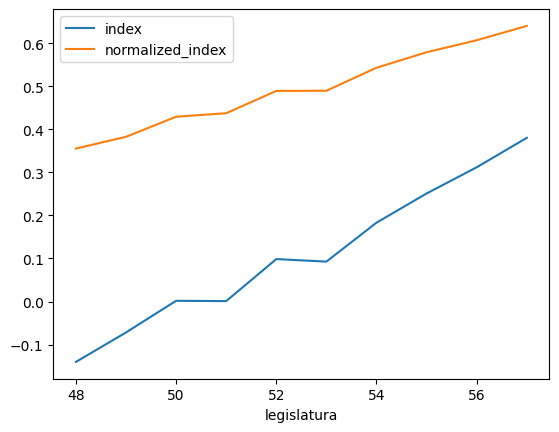

In [39]:
pd.DataFrame(sorted(aggeregated_index, key=lambda x: x["legislatura"])).plot(
    x="legislatura", y=["index", "normalized_index"], kind="line"
)

In [40]:
df_joined = df_with_ipp.join(df_with_equality)

<Axes: xlabel='equality_weight_normalized', ylabel='ipp'>

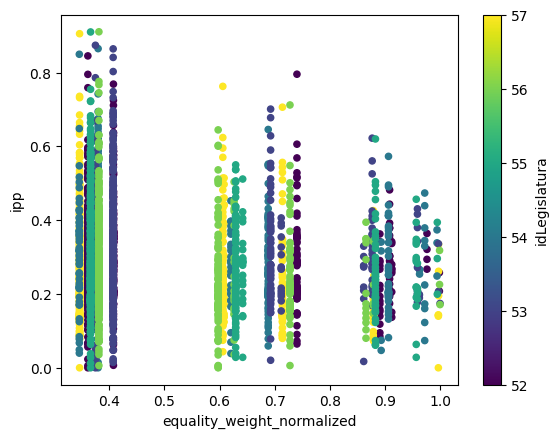

In [41]:
# df_joined.loc[pd.IndexSlice[:, 57], :].reset_index().plot.scatter(
#     x="equality_weight", y="ipp", c="idLegislatura", cmap="viridis"
# )
df_joined.reset_index().plot.scatter(
    x="equality_weight_normalized", y="ipp", c="idLegislatura", cmap="viridis"
)

## Add Cohesion INdex

In [42]:
def treat_name(name: str):
    return (
        str(name)
        .replace(".", "")
        .replace(" ", "")
        .replace("-", "")
        .replace("'", "")
        .replace("  ", " ")
        .lower()
    )

In [43]:
df_cohesion = pd.read_csv("./src/indices/indice_coesao_interna_perfil.csv")

df_cohesion["idLegislatura"] = 56
df_cohesion["name_treated"] = df_cohesion["Profile"].apply(treat_name)

In [44]:
df_to_merge = df_joined.reset_index()
df_to_merge["name_treated"] = df_to_merge["ultimoStatus.nome"].apply(treat_name)

In [45]:
df_m = df_to_merge.merge(
    df_cohesion,
    left_on=["name_treated", "idLegislatura"],
    right_on=["name_treated", "idLegislatura"],
    how="left",
)
df_m.head()

,id,idLegislatura,Unnamed: 0,ultimoStatus.nome,ultimoStatus.siglaPartido,sexo,dataNascimento,escolaridade,idade_posse,tempo_atuacao_dias_cum_ln,...,equality_index_normalized,name_treated,Profile,Mean_Cosine,Median_Cosine,Partido,Estado,total_posts_profile_antes_filtro,total_posts_profile_depois_filtro,num_publicacoes_neste_df
0,62926,52,60,PASTOR REINALDO,PTB,M,1949-02-14,Superior Incompleto,53,7.286876,...,0.489235,pastorreinaldo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,64224,52,61,ROBÉRIO NUNES,PFL,M,1964-11-03,Superior,38,7.286876,...,0.489235,robérionunes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,64960,52,62,MARIA HELENA,MDB,F,1949-06-15,Superior,53,7.286876,...,0.489235,mariahelena,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,65511,52,82,MIGUEL ARRAES,PSB,M,1916-12-15,Superior,74,7.767264,...,0.489235,miguelarraes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65551,52,85,WAGNER LAGO,PDT,M,1944-02-15,Superior,42,7.956477,...,0.489235,wagnerlago,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Mean_Cosine', ylabel='ipp'>

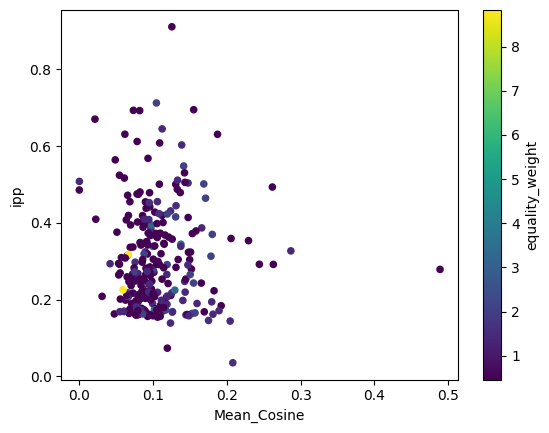

In [46]:
df_m.plot.scatter(x="Mean_Cosine", y="ipp", c="equality_weight", cmap="viridis")

# Calculate Quality Index

In [51]:
index_dimensions = [
    'equality_weight_normalized',
    'ipp',
    'Median_Cosine',
]
df_m['quality_index'] = df_m[index_dimensions].mean(axis=1)
df_m[['quality_index', *index_dimensions]].describe()

,quality_index,equality_weight_normalized,ipp,Median_Cosine
count,6250.000000,6250.000000,3764.000000,269.000000
mean,0.415877,0.478112,0.292040,0.007493
std,0.138618,0.168832,0.136539,0.041998
min,0.151642,0.345503,0.000000,-0.000068
25%,0.338685,0.379595,0.195398,-0.000005
50%,0.405174,0.407404,0.271698,0.000038
75%,0.442544,0.483443,0.369342,0.000427
max,0.999985,1.000000,0.910966,0.547412


In [52]:
df_m.to_excel("./outputs/df_m_v1.xlsx")